In [ ]:
from qiskit import QuantumCircuit
import qiskit
from qiskit import transpile
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Operator
from math import pi
import numpy as np
from matplotlib import pyplot as plt

from sqlalchemy.orm import joinedload
from sqlalchemy import select, func

from benchmarklib import BenchmarkDatabase
from benchmarklib.runners import BatchQueue

from experiments import ExperimentProblem, ExperimentTrial

TAG = "rbf_fidelity_comparison"

service = QiskitRuntimeService()
backend = service.backend("ibm_rensselaer")

db = BenchmarkDatabase("experiments.db", ExperimentProblem, ExperimentTrial)

In [3]:
# hop over to RandomBooleanFunctions to import RBF classes
%cd ../RandomBooleanFunctions/
from rbf import RandomBooleanFunction, RandomBooleanFunctionTrial
%cd ../experiments/

/home/eriku/projects/Python2QCCompiler/RandomBooleanFunctions
/home/eriku/projects/Python2QCCompiler/experiments


/home/eriku/miniconda3/envs/tweedledum-dev/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [4]:
rbf_db = BenchmarkDatabase("../RandomBooleanFunctions/rbf.db", RandomBooleanFunction, RandomBooleanFunctionTrial)

In [9]:
from qiskit.transpiler import Layout

def copy_layout_without_ancillas(original_layout):
    """
    Create a copy of a Layout excluding ancilla qubits.
    
    Args:
        original_layout: The Layout object to copy
        
    Returns:
        A new Layout with only non-ancilla qubits
    """
    new_layout = Layout()
    
    # Iterate through the layout (physical -> virtual mapping)
    for physical_qubit, virtual_qubit in original_layout.get_physical_bits().items():
        # Check if the virtual qubit's register name is NOT "ancilla"
        if virtual_qubit._register.name != "ancilla":
            new_layout.add(virtual_qubit, physical_qubit)
    
    return new_layout

In [ ]:
def create_trials(rbf_trial):
    qc = rbf_trial.circuit_pretranspile
    initial_layout = copy_layout_without_ancillas(rbf_trial.circuit.layout.initial_layout)
    original_transpiled = transpile(qc, backend=backend, optimization_level=3, initial_layout=initial_layout)
    qc.remove_final_measurements()
    qc.barrier()
    qc.append(qc.inverse(), qc.qubits)
    qc.measure_all()
    transpiled = transpile(qc, backend=backend, optimization_level=3, initial_layout=initial_layout)
    
    experiment_orig = db.get_or_create(
        ExperimentProblem,
        tag=TAG,
        n=transpiled.num_qubits,
        name=str(rbf_trial.problem_id) + "+orig"
    )
    experiment_inv = db.get_or_create(
        ExperimentProblem,
        tag=TAG,
        n=transpiled.num_qubits,
        name=str(rbf_trial.problem_id) + "+inv"
    )

    trial_orig = ExperimentTrial(
        problem=experiment_orig,
        circuit=original_transpiled,
        circuit_pretranspile=rbf_trial.circuit_pretranspile,
        extra_data={
            "original_fidelity": rbf_trial.calculate_success_rate(),
            "original_input_state": rbf_trial.input_state,
            "expected_output": rbf_trial.total_expected_results()
        }
    )

    trial_inv = ExperimentTrial(
        problem=experiment_inv,
        circuit=transpiled,
        circuit_pretranspile=qc,
        extra_data={
            "original_fidelity": rbf_trial.calculate_success_rate(),
            "original_input_state": rbf_trial.input_state,
            "expected_output": "0"*transpiled.num_qubits
        }
    )

    return (trial_orig, trial_inv)


In [ ]:
# Somehow it was faster to load all the ids that match this filter and shuffle using numpy instead
# of having the database do it
original_trial_ids = rbf_db.query(
    select(RandomBooleanFunctionTrial.id)
    .join(RandomBooleanFunctionTrial.problem)
    #.options(joinedload(RandomBooleanFunctionTrial.problem))
    .where(RandomBooleanFunctionTrial._circuit_qpy != None, RandomBooleanFunctionTrial._circuit_pretranspile_qpy != None, RandomBooleanFunctionTrial.circuit_num_qubits >= 1, RandomBooleanFunctionTrial.circuit_num_qubits <= 10)
    #.order_by(func.random())
    #.limit(1000)
)
import json
with open("rbf_fidelity_comparison_trial_ids.json", "w") as f:
    json.dump(original_trial_ids, f)
    
np.random.shuffle(original_trial_ids)
original_trial_ids = original_trial_ids[:1000]

original_trials = rbf_db.query(
    select(RandomBooleanFunctionTrial)
    .options(joinedload(RandomBooleanFunctionTrial.problem))
    .where(RandomBooleanFunctionTrial.id.in_(original_trial_ids))
    )

In [ ]:
with BatchQueue(db, backend=backend, shots=4096) as q:
    for i, orig_trial in enumerate(original_trials):
        for trial in create_trials(orig_trial):
            q.enqueue(trial, trial.circuit, run_simulation=False)
        if i % 50 == 0:
            print(f"{i} / {len(original_trials)}")

In [15]:
await db.update_all_pending_results(service=service)

### Visualize Results

In [7]:
def calculate_fidelity(trial):
    counts = trial.counts
    successful_counts = counts.get(trial.extra_data["expected_output"], 0)
    total_counts = sum(counts.values())
    fidelity = successful_counts / total_counts if total_counts > 0 else 0.0
    return fidelity

In [36]:
# Since the two trials for each oracle are stored as separate experiment problems
# we need to first collect them with a mapping of the same RBF problem id to both fidelities
# and then combine them into lists for comparison
_fidelity_orig = {}
_fidelity_inv = {}
_colors = {}
for trial in db.query(
    select(ExperimentTrial)
    .join(ExperimentTrial.problem)
    .where(ExperimentProblem.tag == TAG)
    .options(joinedload(ExperimentTrial.problem))
    ):
    rbf_problem_id = int(trial.problem.name.split("+")[0])
    fidelity = calculate_fidelity(trial)
    input_state = trial.extra_data["original_input_state"]
    if trial.problem.name.endswith("+orig"):
        _fidelity_orig[(rbf_problem_id, input_state)] = fidelity
        _colors[(rbf_problem_id, input_state)] = np.log(trial.circuit_depth)
    elif trial.problem.name.endswith("+inv"):
        _fidelity_inv[(rbf_problem_id, input_state)] = fidelity

fidelity_orig = []
fidelity_inv = []
colors = []
for key in _fidelity_orig.keys():
    fidelity_orig.append(_fidelity_orig[key])
    fidelity_inv.append(_fidelity_inv[key])
    colors.append(_colors[key])

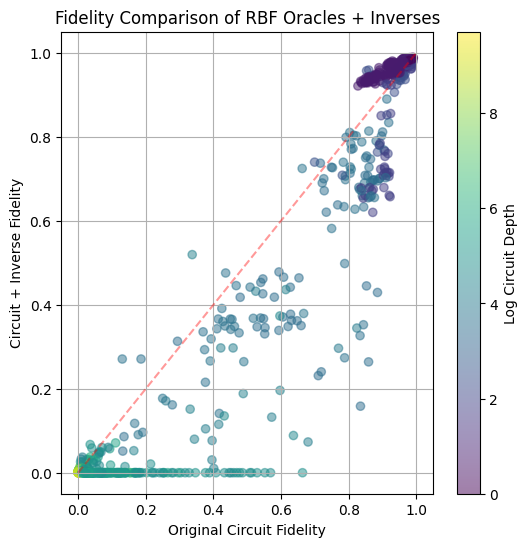

In [38]:
plt.figure(figsize=(6,6))
plt.scatter(fidelity_orig, fidelity_inv, c=colors, alpha=0.5)
plt.plot([0,1], [0,1], color='red', linestyle='--', alpha=0.4)
plt.xlabel("Original Circuit Fidelity")
plt.ylabel("Circuit + Inverse Fidelity")
plt.title("Fidelity Comparison of RBF Oracles + Inverses")
plt.grid(True)
plt.colorbar(label='Log Circuit Depth')
plt.show()